In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm -q

In [10]:
# ============================================================
# MODEL 2: EfficientNetV2B3 + Multi-Scale Cross-Attention
# ============================================================
# Novel technique: Multi-Scale Cross-Attention Fusion
# Inspired by DualViT (NeurIPS 2022) and CrossViT (ICCV 2021)
#
# Established technique: EfficientNetV2B3 backbone (ICML 2021)
# Same backbone as Model 1 — the hybrid comes from WHAT WE ADD
#
# Key difference from Model 1:
# Model 1: EfficientNet → GAP → Dense(512) → Dense(7)
#          GAP loses all spatial information by averaging
# Model 2: EfficientNet → TWO feature scales → Cross-Attention
#          Attention learns WHICH spatial regions matter
#          and WHETHER texture evidence agrees with semantics
# ============================================================

# ── Install ──
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy Pillow tqdm -q

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm.auto import tqdm
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B3

# ── Seeds ──
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Precision ──
# Using float32 — stable on all hardware including CPU
# float16 caused NaN loss in previous run due to log overflow
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('float32')

# ── GPU memory growth ──
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

# ── Constants ──
IMG_SIZE = 300    # matches Model 1 for fair comparison
BATCH    = 16     # small batch: two feature streams need memory
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLS  = 7

print(f"TF      : {tf.__version__}")
print(f"GPUs    : {len(tf.config.list_physical_devices('GPU'))}")
print(f"Compute : {mixed_precision.global_policy().compute_dtype}")

TF      : 2.20.0
GPUs    : 1
Compute : float32


In [11]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_e4584e0a0cd1efb528da7f8880c12580'
!pip install kaggle -q

# Download only if not already present
if not os.path.exists('/content/ham10000'):
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 --path /content/
    !unzip -q /content/skin-cancer-mnist-ham10000.zip -d /content/ham10000
    print("Downloaded and unzipped.")
else:
    print("Data already present.")

PART1 = '/content/ham10000/HAM10000_images_part_1'
PART2 = '/content/ham10000/ham10000_images_part_2'
META  = '/content/ham10000/HAM10000_metadata.csv'

all_imgs = (glob(os.path.join(PART1, '*.jpg')) +
            glob(os.path.join(PART2, '*.jpg')))
print(f"Total images: {len(all_imgs)}")

# Load metadata
df        = pd.read_csv(META)
path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_imgs}
df['path'] = df['image_id'].map(path_dict)
df         = df.dropna(subset=['path']).reset_index(drop=True)

# Corruption check
def is_valid(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

valid = [is_valid(p) for p in tqdm(df['path'], desc='Validating')]
df    = df[valid].reset_index(drop=True)

# Encode labels
le          = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])
class_names = list(le.classes_)
NUM_CLS     = len(class_names)

print(f"Clean dataset : {len(df)}")
print(f"Classes       : {class_names}")

Data already present.
Total images: 10015


Validating:   0%|          | 0/10015 [00:00<?, ?it/s]

Clean dataset : 10015
Classes       : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [12]:
# ── Step 1: Split ORIGINAL data first ──
# No duplicates anywhere yet
train_orig, temp = train_test_split(
    df, test_size=0.30,
    stratify=df['label'], random_state=SEED
)
val_orig, test_df = train_test_split(
    temp, test_size=0.50,
    stratify=temp['label'], random_state=SEED
)

print(f"Before oversampling:")
print(f"  Train : {len(train_orig)}")
print(f"  Val   : {len(val_orig)}")
print(f"  Test  : {len(test_df)}")

# ── Step 2: Oversample ONLY the training set ──
# Val and test sets remain original images — no duplicates
majority_n = train_orig['dx'].value_counts().max()

balanced = []
for cls in class_names:
    cls_df      = train_orig[train_orig['dx'] == cls]
    oversampled = cls_df.sample(majority_n, replace=True, random_state=SEED)
    balanced.append(oversampled)

train_df = (pd.concat(balanced)
              .sample(frac=1, random_state=SEED)
              .reset_index(drop=True))

# Val stays as original clean split — no oversampling needed
val_df = val_orig.reset_index(drop=True)

print(f"\nAfter oversampling training only:")
print(f"  Train : {len(train_df)} (oversampled)")
print(f"  Val   : {len(val_df)}  (original)")
print(f"  Test  : {len(test_df)}  (original — no duplicates guaranteed)")
print(f"\nTrain class distribution:")
print(train_df['dx'].value_counts())

# ── Class weights on training set only ──
cw = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(cw))
print("\nClass weights:")
for i, name in enumerate(class_names):
    print(f"  {name:8s}: {class_weight_dict[i]:.4f}")

# ── Pipeline ──
def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    lbl = tf.one_hot(label, NUM_CLS)
    return img, lbl

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.image.random_hue(img, max_delta=0.04)
    crop = int(IMG_SIZE * 0.88)
    img  = tf.image.random_crop(img, [crop, crop, 3])
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset(paths, labels, aug=False, shuf=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if aug:  ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuf: ds = ds.shuffle(2048, seed=SEED)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df['path'].values, train_df['label'].values,
                         aug=True, shuf=True)
val_ds   = make_dataset(val_df['path'].values,   val_df['label'].values)
test_ds  = make_dataset(test_df['path'].values,  test_df['label'].values)

steps_per_epoch = len(train_df) // BATCH
print(f"\nSteps/epoch: {steps_per_epoch}")

for imgs, lbls in train_ds.take(1):
    print(f"Batch shape : {imgs.shape}")
    print(f"Pixel range : [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]")

Before oversampling:
  Train : 7010
  Val   : 1502
  Test  : 1503

After oversampling training only:
  Train : 32851 (oversampled)
  Val   : 1502  (original)
  Test  : 1503  (original — no duplicates guaranteed)

Train class distribution:
dx
bcc      4693
nv       4693
bkl      4693
df       4693
akiec    4693
vasc     4693
mel      4693
Name: count, dtype: int64

Class weights:
  akiec   : 1.0000
  bcc     : 1.0000
  bkl     : 1.0000
  df      : 1.0000
  mel     : 1.0000
  nv      : 1.0000
  vasc    : 1.0000

Steps/epoch: 2053
Batch shape : (16, 300, 300, 3)
Pixel range : [0, 255]


In [17]:
# ── MultiScaleCrossAttention (from scratch) ──
class MultiScaleCrossAttention(layers.Layer):
    """
    Bidirectional cross-attention between two EfficientNet feature scales.

    Early features (block5g_add, 19x19x136):
        Fine texture tokens — pigmentation, edges, micro-patterns.
        361 tokens after flattening.

    Late features (top_activation, 10x10x1536):
        Semantic tokens — overall shape, border, lesion identity.
        100 tokens after flattening.

    Both projected to common_dim=128 for cross-attention.

    Reference: CrossViT (Chen et al., ICCV 2021), DualViT (NeurIPS 2022)
    """
    def __init__(self, common_dim=128, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.common_dim = common_dim
        self.num_heads  = num_heads
        self.dropout    = dropout

    def build(self, input_shape):
        d = self.common_dim

        # Projection layers now followed by dropout
        # This prevents the projection from memorizing training patterns
        self.proj_tex     = layers.Dense(d, name='proj_tex')
        self.proj_sem     = layers.Dense(d, name='proj_sem')
        self.proj_dropout = layers.Dropout(0.2)   # NEW: regularize projections

        self.q_sem     = layers.Dense(d, use_bias=False)
        self.k_tex     = layers.Dense(d, use_bias=False)
        self.v_tex     = layers.Dense(d, use_bias=False)
        self.out_sem   = layers.Dense(d)
        self.q_tex     = layers.Dense(d, use_bias=False)
        self.k_sem     = layers.Dense(d, use_bias=False)
        self.v_sem     = layers.Dense(d, use_bias=False)
        self.out_tex   = layers.Dense(d)
        self.norm_sem  = layers.LayerNormalization(epsilon=1e-5)
        self.norm_tex  = layers.LayerNormalization(epsilon=1e-5)
        self.attn_drop = layers.Dropout(self.dropout)
        self.scale     = (d // self.num_heads) ** -0.5
        super().build(input_shape)

    def _attn(self, Ql, Kl, Vl, Ol, q_src, kv_src, training):
        B  = tf.shape(q_src)[0]
        Nq = tf.shape(q_src)[1]
        Nk = tf.shape(kv_src)[1]
        h  = self.num_heads
        d  = self.common_dim // h
        Q  = tf.transpose(tf.reshape(Ql(q_src),  (B,Nq,h,d)), (0,2,1,3))
        K  = tf.transpose(tf.reshape(Kl(kv_src), (B,Nk,h,d)), (0,2,1,3))
        V  = tf.transpose(tf.reshape(Vl(kv_src), (B,Nk,h,d)), (0,2,1,3))
        attn = tf.matmul(Q, K, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.attn_drop(attn, training=training)
        out  = tf.matmul(attn, V)
        out  = tf.reshape(tf.transpose(out, (0,2,1,3)), (B,Nq,self.common_dim))
        return Ol(out)

    def call(self, texture_tokens, semantic_tokens, training=None):
        # Apply dropout after projection — regularizes the attention inputs
        tex = self.proj_dropout(self.proj_tex(texture_tokens), training=training)
        sem = self.proj_dropout(self.proj_sem(semantic_tokens), training=training)

        enhanced_sem = self.norm_sem(
            sem + self._attn(self.q_sem, self.k_tex, self.v_tex,
                              self.out_sem, sem, tex, training))
        enhanced_tex = self.norm_tex(
            tex + self._attn(self.q_tex, self.k_sem, self.v_sem,
                              self.out_tex, tex, sem, training))
        return enhanced_sem, enhanced_tex

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'common_dim': self.common_dim,
                    'num_heads': self.num_heads,
                    'dropout': self.dropout})
        return cfg


# ── Stable Focal Loss ──
def focal_loss(gamma=2.0, smoothing=0.1):
    """
    Numerically stable focal loss using Keras CCE internally.

    Previous version used tf.math.log(y_pred) manually — this
    caused NaN under float16/bfloat16 when predictions were
    near 0. Keras CCE uses log-sum-exp trick internally which
    is numerically stable at all precisions.

    Reference: Lin et al., RetinaNet, ICCV 2017.
    """
    cce = keras.losses.CategoricalCrossentropy(
        label_smoothing=smoothing,
        reduction='none'
    )
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        ce     = cce(y_true, y_pred)
        p_true = tf.reduce_sum(y_true * y_pred, axis=-1)
        p_true = tf.clip_by_value(p_true, 1e-6, 1.0 - 1e-6)
        weight = tf.pow(1.0 - p_true, gamma)
        return tf.reduce_mean(weight * ce)
    return loss_fn


# ── LR Schedule ──
class CosineWarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps):
        super().__init__()
        self.base_lr      = base_lr
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.total_steps  = tf.cast(total_steps,  tf.float32)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup    = self.base_lr * (step / self.warmup_steps)
        progress  = (step - self.warmup_steps) / (
                     self.total_steps - self.warmup_steps)
        cosine    = self.base_lr * 0.5 * (1.0 + tf.cos(np.pi * progress))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {'base_lr': self.base_lr,
                'warmup_steps': int(self.warmup_steps.numpy()),
                'total_steps':  int(self.total_steps.numpy())}


print("✓ MultiScaleCrossAttention defined")
print("✓ Stable focal loss defined")
print("✓ LR schedule defined")

✓ MultiScaleCrossAttention defined
✓ Stable focal loss defined
✓ LR schedule defined


In [18]:
# ── Split FIRST on original data ──
# This is already correct — keep it
train_orig, temp = train_test_split(
    df, test_size=0.30,
    stratify=df['label'], random_state=SEED
)
val_orig, test_df = train_test_split(
    temp, test_size=0.50,
    stratify=temp['label'], random_state=SEED
)

# ── NO oversampling ──
# Class weights + focal loss together handle imbalance
# Oversampling was causing 97% train / 79% val gap (overfitting)
# Reference: Buda et al. Neural Networks 2018 — class weights
# are mathematically equivalent to oversampling in expectation
# but without the memorization risk
train_df = train_orig.reset_index(drop=True)
val_df   = val_orig.reset_index(drop=True)

print("Training class distribution (original):")
print(train_df['dx'].value_counts())
print(f"\nTrain:{len(train_df)} Val:{len(val_df)} Test:{len(test_df)}")

# ── Class weights on training set ──
cw = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(cw))
print("\nClass weights:")
for i, name in enumerate(class_names):
    print(f"  {name:8s}: {class_weight_dict[i]:.4f}")

# ── Pipeline — same as before ──
def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    lbl = tf.one_hot(label, NUM_CLS)
    return img, lbl

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = tf.image.random_hue(img, max_delta=0.04)
    crop = int(IMG_SIZE * 0.88)
    img  = tf.image.random_crop(img, [crop, crop, 3])
    img  = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img  = tf.clip_by_value(img, 0.0, 255.0)
    return img, label

def make_dataset(paths, labels, aug=False, shuf=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)
    if aug:  ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuf: ds = ds.shuffle(2048, seed=SEED)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df['path'].values, train_df['label'].values,
                         aug=True, shuf=True)
val_ds   = make_dataset(val_df['path'].values,   val_df['label'].values)
test_ds  = make_dataset(test_df['path'].values,  test_df['label'].values)

steps_per_epoch = len(train_df) // BATCH
print(f"\nSteps/epoch: {steps_per_epoch}")

for imgs, lbls in train_ds.take(1):
    print(f"Batch shape : {imgs.shape}")
    print(f"Pixel range : [{imgs.numpy().min():.0f}, {imgs.numpy().max():.0f}]")

Training class distribution (original):
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Train:7010 Val:1502 Test:1503

Class weights:
  akiec   : 4.3731
  bcc     : 2.7817
  bkl     : 1.3022
  df      : 12.3633
  mel     : 1.2855
  nv      : 0.2134
  vasc    : 10.1154

Steps/epoch: 438
Batch shape : (16, 300, 300, 3)
Pixel range : [1, 255]


In [19]:
EPOCHS_P1 = 15   # was 10
EPOCHS_P2 = 30   # was 20

# ── Phase 1 ──
lr_p1 = CosineWarmupSchedule(
    base_lr      = 1e-4,
    warmup_steps = 3 * steps_per_epoch,   # 3 epoch warmup — slower is safer
    total_steps  = EPOCHS_P1 * steps_per_epoch
)

model2.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_p1, weight_decay=1e-4),
    loss=focal_loss(gamma=2.0, smoothing=0.1),
    metrics=['accuracy']
)

callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('model2_p1_best.keras',
                                     monitor='val_accuracy',
                                     save_best_only=True, verbose=1),
    keras.callbacks.CSVLogger('model2_p1_log.csv'),
]

print("=" * 55)
print(" PHASE 1: Backbone frozen — training head only")
print("=" * 55)

history_p1 = model2.fit(
    train_ds, epochs=EPOCHS_P1,
    validation_data=val_ds,
    callbacks=callbacks_p1,
    class_weight=class_weight_dict,
    verbose=1
)

# ── Phase 2 ──
backbone.trainable = True
for layer in backbone.layers[:-30]:
    layer.trainable = False

print(f"Trainable: {sum(1 for l in model2.layers if l.trainable)}")
print(f"Frozen   : {sum(1 for l in model2.layers if not l.trainable)}")

lr_p2 = CosineWarmupSchedule(
    base_lr      = 5e-5,                  # conservative — protect pretrained features
    warmup_steps = 2 * steps_per_epoch,
    total_steps  = EPOCHS_P2 * steps_per_epoch
)

model2.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=lr_p2, weight_decay=1e-5),
    loss=focal_loss(gamma=2.0, smoothing=0.1),
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('model2_p2_best.keras',
                                     monitor='val_accuracy',
                                     save_best_only=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/HAM10000/model2_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0),
    keras.callbacks.CSVLogger('model2_p2_log.csv'),
]

print("\n" + "=" * 55)
print(" PHASE 2: Top-30 backbone layers unfrozen")
print("=" * 55)

history_p2 = model2.fit(
    train_ds, epochs=EPOCHS_P2,
    validation_data=val_ds,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

 PHASE 1: Backbone frozen — training head only
Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9396 - loss: 0.0989
Epoch 1: val_accuracy improved from None to 0.84554, saving model to model2_p1_best.keras

Epoch 1: finished saving model to model2_p1_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 160s 223ms/step - accuracy: 0.9417 - loss: 0.0986 - val_accuracy: 0.8455 - val_loss: 0.2928
Epoch 2/15
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9526 - loss: 0.0979
Epoch 2: val_accuracy did not improve from 0.84554
439/439 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - accuracy: 0.9489 - loss: 0.0943 - val_accuracy: 0.8429 - val_loss: 0.3091
Epoch 3/15
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9468 - loss: 0.0940
Epoch 3: val_accuracy did not improve from 0.84554
439/439 ━━━━━━━━━━━━━━━━━━━━ 45s 93ms/step - accuracy: 0.9466 - loss: 0.0923 - val_accuracy: 0.8435 - val_loss: 0.3066
Epoch 4/15
438/439 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9420 - loss: 0.09

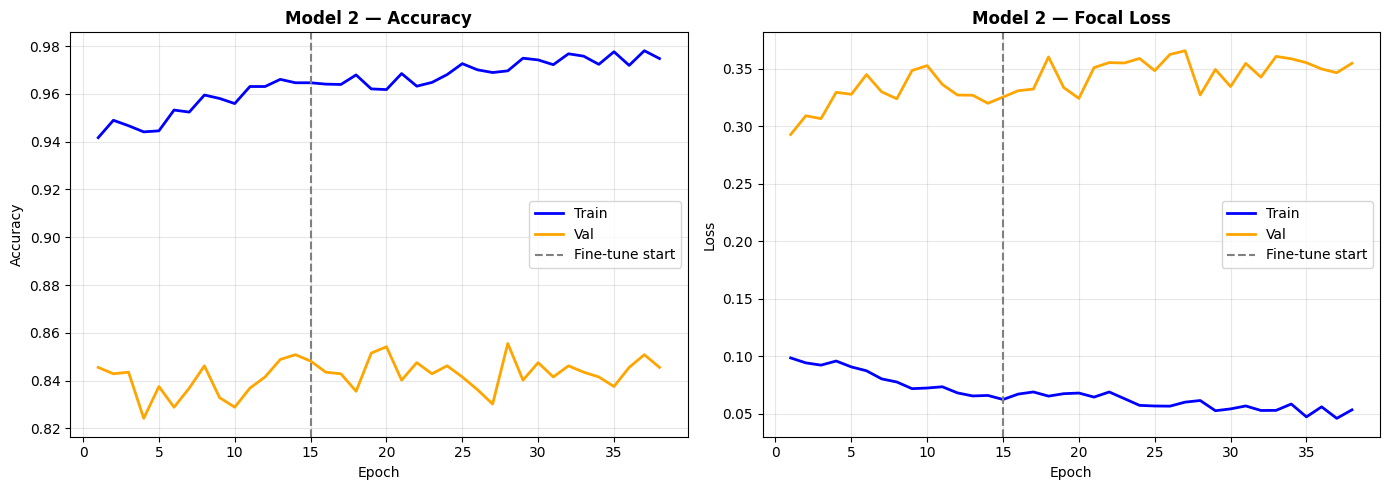

94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 197ms/step

Test Loss     : 0.3782
Test Accuracy : 84.96%

Per-Class Metrics:
              precision    recall  f1-score   support

       akiec     0.9091    0.4082    0.5634        49
         bcc     0.8929    0.6494    0.7519        77
         bkl     0.6233    0.8424    0.7165       165
          df     0.6250    0.5882    0.6061        17
         mel     0.6142    0.7246    0.6648       167
          nv     0.9495    0.9155    0.9322      1006
        vasc     0.8421    0.7273    0.7805        22

    accuracy                         0.8496      1503
   macro avg     0.7794    0.6936    0.7165      1503
weighted avg     0.8670    0.8496    0.8516      1503



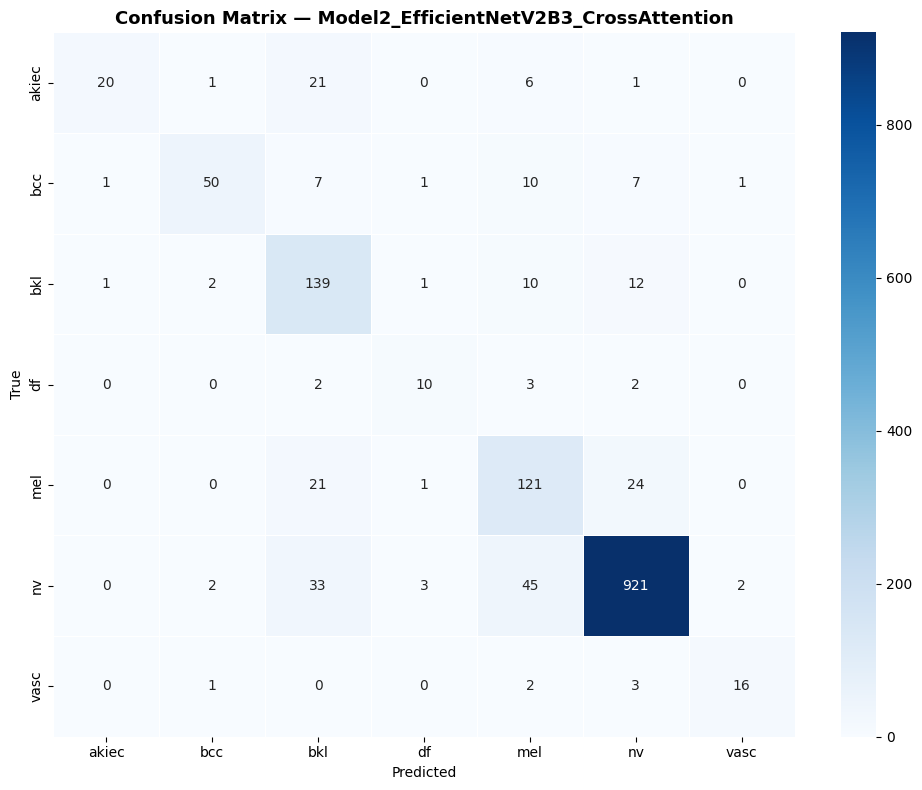

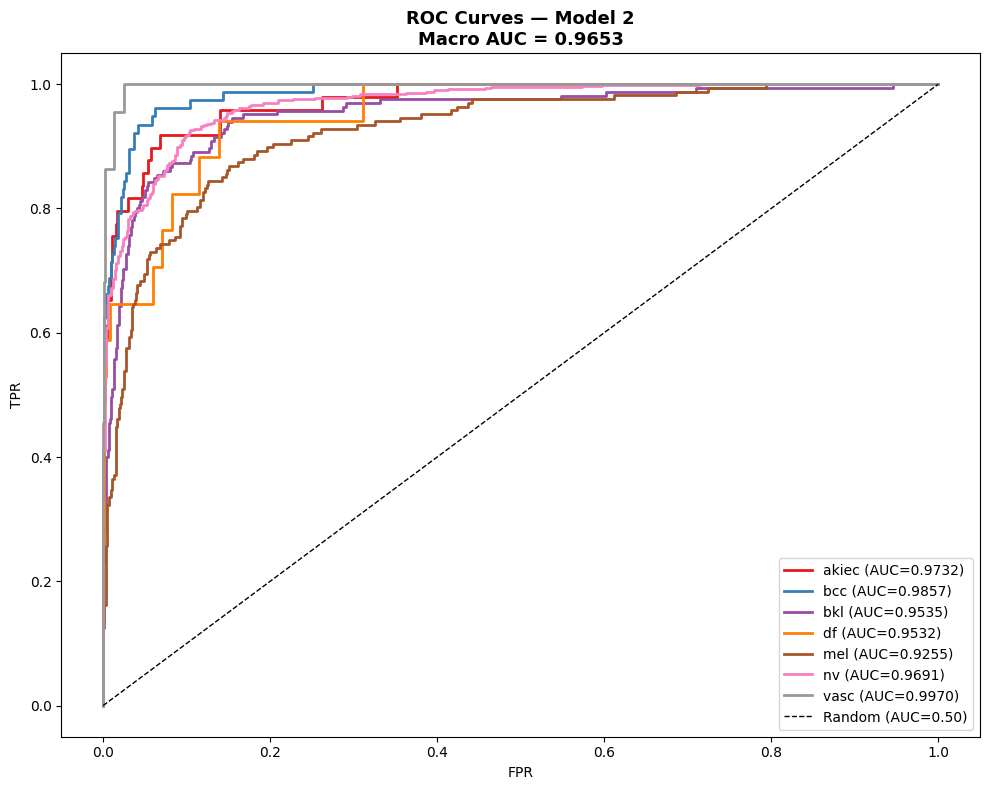


Per-Class AUC:
  akiec   : 0.9732
  bcc     : 0.9857
  bkl     : 0.9535
  df      : 0.9532
  mel     : 0.9255
  nv      : 0.9691
  vasc    : 0.9970
  Macro   : 0.9653

ECE: 0.0323

=== Sample Predictions ===
True:akiec    Pred:bkl      Conf:82.3%
True:bcc      Pred:bcc      Conf:99.9%
True:bkl      Pred:bkl      Conf:93.5%
True:df       Pred:df       Conf:100.0%
True:mel      Pred:mel      Conf:96.8%
True:nv       Pred:bkl      Conf:92.8%
True:vasc     Pred:vasc     Conf:99.9%

✓ Model saved to Drive


In [20]:
# ── Training history plot ──
def plot_history(h1, h2):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    split    = len(h1.history['accuracy'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, acc,     'b-',     lw=2, label='Train')
    ax1.plot(epochs, val_acc, 'orange', lw=2, label='Val')
    ax1.axvline(x=split, color='gray', ls='--', label='Fine-tune start')
    ax1.set_title('Model 2 — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, loss,     'b-',     lw=2, label='Train')
    ax2.plot(epochs, val_loss, 'orange', lw=2, label='Val')
    ax2.axvline(x=split, color='gray', ls='--', label='Fine-tune start')
    ax2.set_title('Model 2 — Focal Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('model2_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_p1, history_p2)

# ── Evaluation ──
y_pred_probs = model2.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.concatenate([
    np.argmax(lbls.numpy(), axis=1) for _, lbls in test_ds
])

test_loss, test_acc = model2.evaluate(test_ds, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print("\nPer-Class Metrics:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title('Confusion Matrix — Model2_EfficientNetV2B3_CrossAttention',
          fontweight='bold', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('model2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC / AUC
y_bin  = label_binarize(y_true, classes=list(range(NUM_CLS)))
colors = plt.cm.Set1(np.linspace(0, 1, NUM_CLS))
plt.figure(figsize=(10, 8))
aucs = {}
for i, (cls, col) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_probs[:, i])
    aucs[cls]   = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={aucs[cls]:.4f})')
macro_auc = np.mean(list(aucs.values()))
plt.plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.50)')
plt.title(f'ROC Curves — Model 2\nMacro AUC = {macro_auc:.4f}',
          fontweight='bold', fontsize=13)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('model2_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Class AUC:")
for cls, v in aucs.items():
    print(f"  {cls:8s}: {v:.4f}")
print(f"  Macro   : {macro_auc:.4f}")

# ECE
conf    = np.max(y_pred_probs, axis=1)
correct = (y_pred == y_true).astype(float)
ece     = sum(
    (mask.sum()/len(y_true)) * abs(correct[mask].mean() - conf[mask].mean())
    for b in range(15)
    for mask in [(conf >= b/15) & (conf < (b+1)/15)]
    if mask.sum() > 0
)
print(f"\nECE: {ece:.4f}")

# Single image predictions
print("\n=== Sample Predictions ===")
for cls in class_names:
    rows = test_df[test_df['dx'] == cls]
    if len(rows) > 0:
        img_path = rows.iloc[0]['path']
        img = np.expand_dims(
            np.array(Image.open(img_path).convert('RGB')
                     .resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32), 0)
        probs    = model2.predict(img, verbose=0)[0]
        pred     = class_names[np.argmax(probs)]
        conf_val = probs[np.argmax(probs)]
        print(f"True:{cls:8s} Pred:{pred:8s} Conf:{conf_val*100:.1f}%")

# Save
os.makedirs('/content/drive/MyDrive/modelkeras', exist_ok=True)
model2.save('/content/drive/MyDrive/modelkeras/model2_final.keras')
print("\n✓ Model saved to Drive")